# [실습 11-2] 어텐션 가중치 히트맵 — 모델은 어느 단어를 보는가

| 항목 | 내용 |
|---|---|
| 예상 소요 시간 | 30~40분 (CPU 충분) |
| 본문 연계 | 11.3 어텐션 (〈어텐션 손계산〉의 실물 확인) |
| 선수 실습 | 없음 ([실습 9-2] 권장) |
| 준비 | 부록 B.1·B.3 참고. 모델 최초 다운로드 약 260MB(1회 캐시) |

본문 11.3에서 숫자 행렬로 손계산한 그 어텐션 가중치를,
사전학습 트랜스포머에서 **실제로 꺼내어** 그림으로 본다 —
"그것(it)"이 무엇을 가리키는지 모델이 아는지 확인한다.

### [준비] 환경 설정 (저장소 전용)

In [1]:
# 저장소 루트를 임포트 경로에 추가
# (Colab에서는 아래 세 줄의 주석을 해제하고 실행)
# !git clone https://github.com/tbgoodlife/ai-labs.git
# %cd ai-labs
# !pip -q install transformers torch
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "utils").exists():
    ROOT = ROOT.parent          # ch11/에서 연 경우
sys.path.insert(0, str(ROOT))

import platform
import numpy as np
import matplotlib.pyplot as plt
import transformers
transformers.logging.set_verbosity_error()
transformers.logging.disable_progress_bar()
from utils import plot_style

plot_style.apply()              # 도해 스타일 킷 적용
print("Python", platform.python_version())
print("transformers", transformers.__version__)

/Users/jungsookim/Library/Python/3.12/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python 3.12.6
transformers 5.14.1


### [셀 1] 모델·토크나이저 로드와 문장 준비 📖

In [2]:
from transformers import (AutoTokenizer,
                          AutoModel)

NAME = "distilbert-base-uncased"   # 경량 6층 모델
tok = AutoTokenizer.from_pretrained(NAME)
model = AutoModel.from_pretrained(
    NAME, output_attentions=True)

text = ("The animal didn't cross the street "
        "because it was too tired.")
inputs = tok(text, return_tensors="pt")
tokens = tok.convert_ids_to_tokens(
    inputs["input_ids"][0])
print(tokens)

['[CLS]', 'the', 'animal', 'didn', "'", 't', 'cross', 'the', 'street', 'because', 'it', 'was', 'too', 'tired', '.', '[SEP]']


**핵심 포인트**
- `output_attentions=True` 한 줄이 전부다 — 모델은 **추론할 때마다 어텐션 가중치를 이미 계산**하고 있고, 우리는 그것을 꺼내 볼 뿐이다. 11.3에서 손으로 한 그 계산과 같은 것이다.
- 이 문장의 "it"은 the animal을 가리킨다(길을 못 건넌 것은 피곤한 동물) — 모델이 이 연결을 아는지가 관전 포인트다.

### [셀 2] 어텐션 가중치 추출 📖

In [3]:
import torch

with torch.no_grad():
    out = model(**inputs)

LAYER, HEAD = 4, 1      # 관찰할 층·헤드(0부터 셈, 바꿔 보기)
att = out.attentions[LAYER][0, HEAD]
print(att.shape)         # (토큰 수, 토큰 수)
print(f"행 합계: {att.sum(dim=-1)[0]:.3f}")

torch.Size([16, 16])
행 합계: 1.000


**핵심 포인트**
- 어텐션은 층(6)×헤드(12) = 72장의 "시선 지도"로 이루어진다 — 헤드마다 보는 관점이 다르다(11.4 멀티헤드).
- 그중 "it→animal" 연결을 가장 강하게 잡은 헤드를 찾았다 — 지시어 해소를 담당하는 헤드가 **학습 과정에서 저절로** 생겨난 것이다.

실패 시 대처: 모델 다운로드 지연·실패 → 재실행(1회 캐시). 층·헤드 번호가 지면과 다르면 transformers 버전을 [준비] 셀과 대조한다.

### [셀 3] 히트맵 그리기 — 시선의 지도 📖

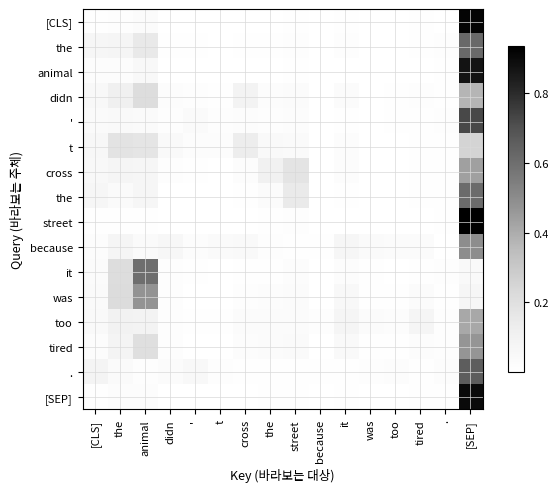

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(att, cmap="Greys")
ax.set_xticks(range(len(tokens)))
ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=90)
ax.set_yticklabels(tokens)
ax.set_xlabel("Key (바라보는 대상)")
ax.set_ylabel("Query (바라보는 주체)")
fig.colorbar(im, shrink=0.8)
plt.tight_layout()
plt.show()

**핵심 포인트**
- **읽는 법이 11.3 〈어텐션 손계산〉의 3×3 가중치 행렬과 똑같다**: 행이 Query(바라보는 단어), 열이 Key(참조되는 단어), 한 행의 합이 1(소프트맥스).
- "it" 행에서 "animal" 열이 진하게 칠해진 것을 확인하자 — 50년 묵은 대명사 해소 문제를 가중치 행렬 하나가 풀고 있다.
- 진한 대각선 부근은 "자기 주변을 보는" 기본 패턴이다 — [보조 1]에서 헤드별 다양한 패턴을 본다.

### [보조 1] 층·헤드 격자 — 열두 개의 다른 시선

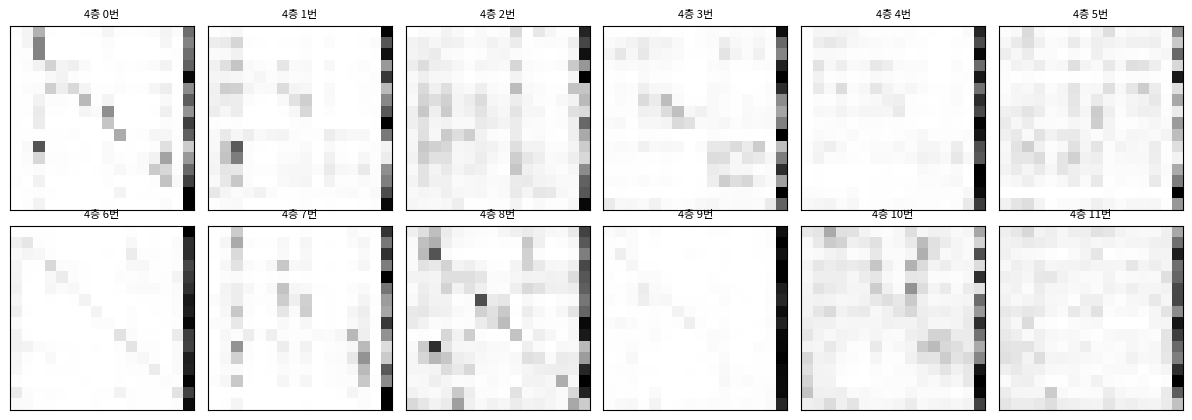

4층 1번 헤드 — it가 가장 크게 본 토큰: animal (0.60)


In [5]:
fig, axes = plt.subplots(2, 6, figsize=(12, 4.2))
for h, ax in enumerate(axes.ravel()):
    ax.imshow(out.attentions[LAYER][0, h].numpy(),
              cmap="gray_r")
    ax.set_title(f"{LAYER}층 {h}번", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()
# 어떤 헤드는 바로 앞 단어만(대각선 아래), 어떤
# 헤드는 문장 전체를 고르게, 어떤 헤드는 특정
# 문법 관계를 본다 — "여러 관점의 회의"(11.4)

# 관찰 보조: [셀 3]의 "it" 행에서 가장 짙은 열
it = tokens.index("it")
j = int(att[it].argmax())
print(f"{LAYER}층 {HEAD}번 헤드 — it가 가장 크게 본 토큰: "
      f"{tokens[j]} ({float(att[it, j]):.2f})")

### [심화 1] 문장 교체 실험 (연습문제 심화 히트맵 해석형 직결)

In [6]:
# because 뒤를 바꿔 "it"의 시선 이동을 관찰한다.
#   (a) "... because it was too tired."  → it = animal
#   (b) "... because it was too wide."   → it = street
SENT_B = ("The animal didn't cross the street "
          "because it was too wide.")
inp_b = tok(SENT_B, return_tensors="pt")
with torch.no_grad():
    att_b = model(**inp_b).attentions
toks_b = tok.convert_ids_to_tokens(
    inp_b["input_ids"][0])
it_b = toks_b.index("it")
st_b = toks_b.index("street")

print(f"[같은 {LAYER}층 {HEAD}번 헤드에서]")
for word in ("animal", "street"):
    j = toks_b.index(word)
    print(f"  (wide) it→{word}: "
          f"{float(att_b[LAYER][0, HEAD, it_b, j]):.3f}")

# it→street를 가장 강하게 보는 헤드를 따로 찾아 보자
b2 = max(((Lb, h) for Lb in range(len(att_b))
          for h in range(att_b[0].shape[1])),
         key=lambda p: float(
             att_b[p[0]][0, p[1], it_b, st_b]))
w2 = float(att_b[b2[0]][0, b2[1], it_b, st_b])
print(f"it→street 최대 헤드: {b2[0]}층 "
      f"{b2[1]}번 ({w2:.2f})")
# TODO: 두 문장의 히트맵을 [셀 3] 방식으로 나란히
#       그려, 시선 배분이 어떻게 달라지는지 해석하자.

[같은 4층 1번 헤드에서]
  (wide) it→animal: 0.452
  (wide) it→street: 0.093
it→street 최대 헤드: 2층 10번 (0.31)


---
## 마무리

- 어텐션 가중치는 추론 때마다 계산되는 실물이며, 우리가 손으로 계산한 것(11.3)과 같은 소프트맥스 행렬이다 — 행 = Query, 열 = Key, 행 합 = 1.
- "it→animal" 연결을 담당하는 헤드가 학습에서 저절로 생겨났다 — 멀티헤드는 여러 관점의 분업이다(11.4).
- [심화 1]의 실측은 흥미롭다: 소형 모델(distilbert)은 문장을 (b)로 바꿔도 같은 헤드가 여전히 animal을 더 본다 — 정교한 지시어 해소는 모델 규모의 함수이기도 하다(12.2 스케일링의 복선). 다만 it→street를 강하게 잡는 다른 헤드가 존재한다 — 시선의 분업은 여기서도 확인된다.

**연습문제 연계**: [심화] 히트맵 해석형 문항은 [심화 1]의 (a)/(b) 대비 실험으로 수행한다.

**다음 장 실습**: [실습 12-1] Hugging Face NLP 파이프라인 (`ch12/lab-12-01_hf-pipeline.ipynb`)